In [1]:
import numpy as np
import params
from basis import *

In [2]:
def cme_gui_test_comp(case,T_test,ind_test,N=10000):
    pf = case.solver([T_test])[0]
    gr = case.run_guillespie(T_test*np.ones(N))

    cme_list,ind_list,gui_list = [],[],[]
    for ind_test in range(8):
        p_cme = marginalize(pf,case.states,ind_test)[1]
        ind_gui,p_gui = np.unique(gr[:,ind_test],return_counts=True)
        p_gui = normalize(p_gui)

        cme_list.append(p_cme)
        ind_list.append(ind_gui)
        gui_list.append(p_gui)

    return cme_list,ind_list,gui_list

In [3]:
#case1 
value = np.array((10., #beta_s
                  1.,   #gamma_s
                  1,  #kAon
                  1,  #kAoff
                  1,  #kApon
                  1,  #kApoff
                  1,  #alpha
                  2,  #alphap
                  2,  #alpha_s
                  1,  #alpha_sp
                  1,  #nu
                  1., #nup
                  1., #kBon
                  1., #kBoff
                  1.  #gammaP
                  ))

In [4]:
init = np.array((1,  #A
                 0,  #Ap
                 0,  #AS
                 0,  #ApS
                 1,  #B
                 0,  #BP
                 1,  #P
                 10 #S
                 ))



In [5]:
case1 = params.case(init,value)


In [6]:
T_test = 10#*np.random.rand()
ind_test = np.random.randint(6)
p_cme,ind_gui,p_gui = cme_gui_test_comp(case1,T_test,ind_test,N=1000000)

In [7]:
from matplotlib import pyplot as plt

In [8]:
for i in range(6):
    print(p_gui[i]-p_cme[i])

[ 0.00039528 -0.00039528]
[-0.00033054  0.00033054]
[ 7.49650948e-05 -7.49650948e-05]
[-0.0001397  0.0001397]
[-0.0002767  0.0002767]
[ 0.0002767 -0.0002767]


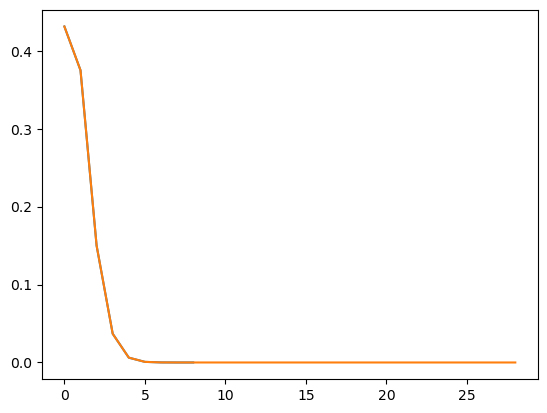

In [9]:
plt.plot(ind_gui[-2],p_gui[-2])
plt.plot(p_cme[-2])

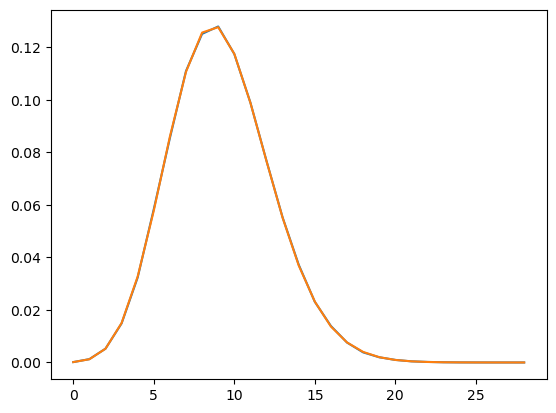

In [10]:
plt.plot(ind_gui[-1],p_gui[-1])
plt.plot(p_cme[-1])